In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df = pd.read_csv('/content/job_postings.csv')

In [ ]:
# Combine skill columns into a single string if needed
df['Skills'] = df['Skills'].astype(str)

In [ ]:
# Clean and Parse Skills
df['Skill List'] = df['Skills'].str.lower().str.replace('[^a-zA-Z0-9, ]', '', regex=True)
df['Skill List'] = df['Skill List'].str.split(',|and|/|&')
df = df.explode('Skill List')
df['Skill List'] = df['Skill List'].str.strip()

* Converts skills to lowercase.
* Removes special characters (like . or /).
* Splits the skill string into a list of individual skills.  
* Explodes the list so that each skill gets its own row (one skill per row).

In [ ]:
# Filter out empty skills
df = df[df['Skill List'] != '']

In [ ]:
# Top 10 Skills Overall
top_skills = df['Skill List'].value_counts().head(10).index
df_top_skills = df[df['Skill List'].isin(top_skills)]

* Calculates the most frequent skills across all job postings.
* Filters the dataset to only include these top 10 skills for visualization.

In [ ]:
top_skills

Index(['python', 'sql', 'communication', 'aws', 'excel', 'tensorflow',
       'nodejs', 'statistics', 'git', 'microservices'],
      dtype='object', name='Skill List')

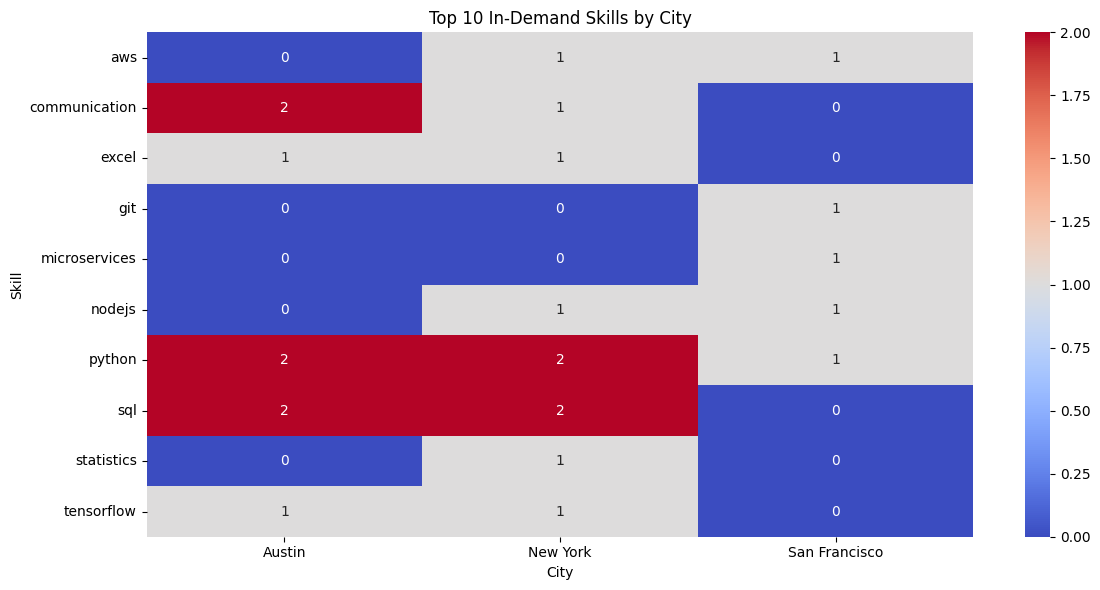

In [ ]:
# Heatmap of top 10 skills by city
heatmap_data = df_top_skills.groupby(['Skill List', 'Location']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='d')
plt.title('Top 10 In-Demand Skills by City')
plt.xlabel('City')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

In [ ]:
# Role-skill Matrix
role_skill_matrix = df.pivot_table(index='Job Title', columns='Skill List', aggfunc='size', fill_value=0)
role_skill_matrix.to_excel('role_skill_matrix.xlsx')

* Builds a matrix where rows = job titles and columns = skills.  
* Values represent how often a skill appears in each role.
* This matrix is saved as an Excel file (role_skill_matrix.xlsx) for further analysis.

In [ ]:
# Print Recommendations
print("\n📌 Top Roles by Frequency:")
print(df['Job Title'].value_counts().head(5))


📌 Top Roles by Frequency:
Job Title
Data Scientist               9
Data Analyst                 8
Machine Learning Engineer    8
Software Engineer            4
Backend Developer            4
Name: count, dtype: int64


In [ ]:
print("\n📌 Top Skills Overall:")
print(df['Skill List'].value_counts().head(10))


📌 Top Skills Overall:
Skill List
python           5
sql              4
communication    3
aws              2
excel            2
tensorflow       2
nodejs           2
statistics       1
git              1
microservices    1
Name: count, dtype: int64


In [ ]:
# Top roles in demand
print(df['Job Title'].value_counts().head(5))

Job Title
Data Scientist               9
Data Analyst                 8
Machine Learning Engineer    8
Software Engineer            4
Backend Developer            4
Name: count, dtype: int64


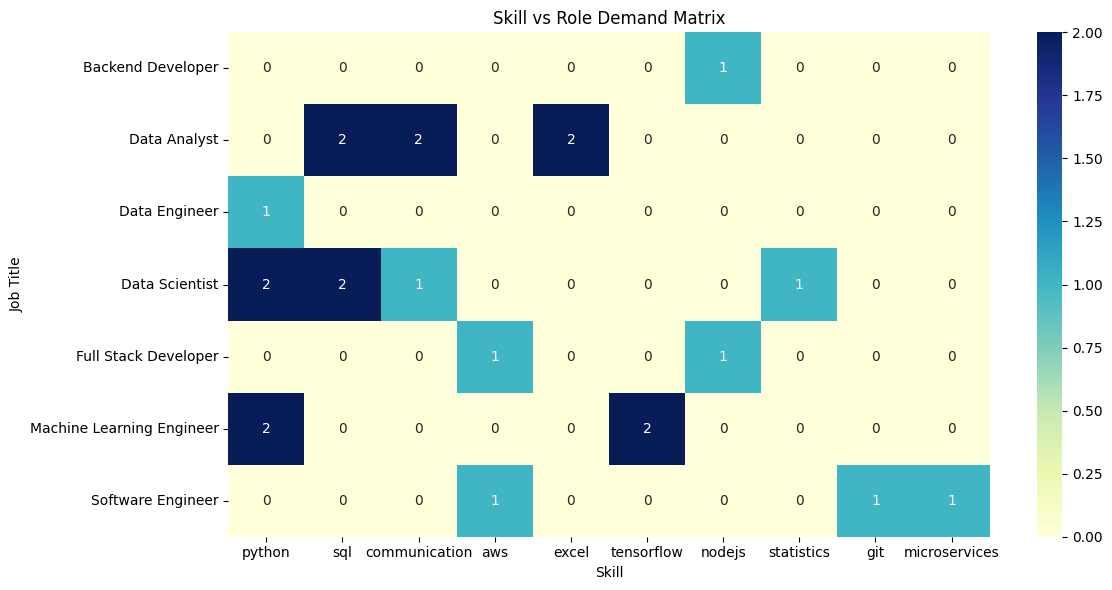

In [ ]:
# Filter to only show top 10 most frequent skills
top_skills = df['Skill List'].value_counts().head(10).index
filtered_matrix = role_skill_matrix[top_skills.intersection(role_skill_matrix.columns)]

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(filtered_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Skill vs Role Demand Matrix')
plt.xlabel('Skill')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()